<a href="https://colab.research.google.com/github/tasmianiha/ML-projects/blob/main/SylhetFlood.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

In [7]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/My Drive/Colab Notebooks/
import pandas as pd
df = pd.read_csv("flooddtsylhet.csv")
df


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/My Drive/Colab Notebooks


,Station_Names,Year,Month,Max_Temp,Min_Temp,Rainfall,Relative_Humidity,Wind_Speed,Cloud_Coverage,Bright_Sunshine,Station_Number,Flood?
0,Sylhet,1956,1,25.8,12.4,10,73.526316,1.344444,1.6,7.715385,41891,0
1,Sylhet,1956,2,29.0,14.2,0,67.035088,1.635185,1.1,8.119231,41891,0
2,Sylhet,1956,3,32.9,18.1,2,65.578947,1.964815,3.2,7.734615,41891,0
3,Sylhet,1956,4,35.8,21.4,229,75.245614,1.914815,3.7,6.863462,41891,0
4,Sylhet,1956,5,35.0,23.4,907,81.333333,1.668519,6.7,6.025000,41891,1
...,...,...,...,...,...,...,...,...,...,...,...,...
691,Sylhet,2013,8,35.3,25.6,520,85.000000,3.300000,7.2,3.900000,41891,1
692,Sylhet,2013,9,36.6,25.3,347,84.000000,3.400000,6.2,4.400000,41891,0
693,Sylhet,2013,10,35.0,23.1,451,81.000000,2.500000,5.0,5.500000,41891,1
694,Sylhet,2013,11,32.5,17.4,0,74.000000,2.400000,0.8,9.200000,41891,0


In [8]:
cols_to_drop = [  'Station_Names', 'Station_Number']
df.drop(columns=cols_to_drop, inplace=True)

In [9]:
print(df.isnull().sum())

Year                 0
Month                0
Max_Temp             0
Min_Temp             0
Rainfall             0
Relative_Humidity    0
Wind_Speed           0
Cloud_Coverage       0
Bright_Sunshine      0
Flood?               0
dtype: int64


In [10]:
print(df.head())
print(df.info())
print(df.describe().round(2))


   Year  Month  Max_Temp  Min_Temp  Rainfall  Relative_Humidity  Wind_Speed  \
0  1956      1      25.8      12.4        10          73.526316    1.344444   
1  1956      2      29.0      14.2         0          67.035088    1.635185   
2  1956      3      32.9      18.1         2          65.578947    1.964815   
3  1956      4      35.8      21.4       229          75.245614    1.914815   
4  1956      5      35.0      23.4       907          81.333333    1.668519   

   Cloud_Coverage  Bright_Sunshine  Flood?  
0             1.6         7.715385       0  
1             1.1         8.119231       0  
2             3.2         7.734615       0  
3             3.7         6.863462       0  
4             6.7         6.025000       1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 696 entries, 0 to 695
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               696 non-null    int64  
 1   M

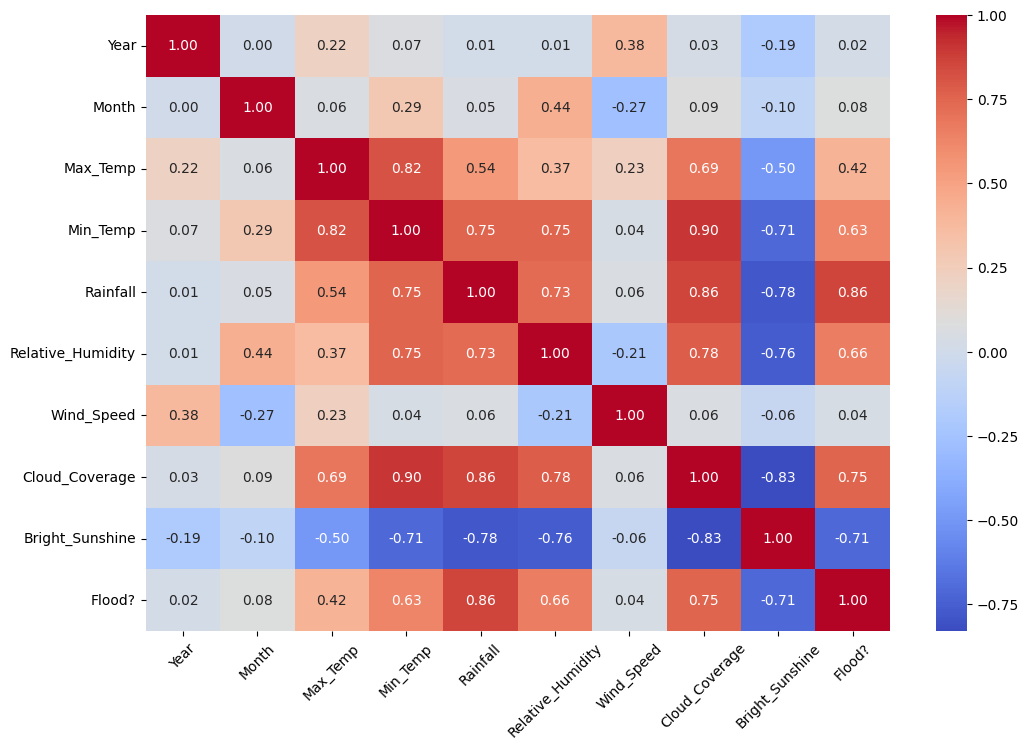

In [11]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr().round(2), annot=True, fmt=".2f", cmap='coolwarm')
plt.xticks(rotation=45)
plt.show()


we see that flood events are highly correlated with rainfall

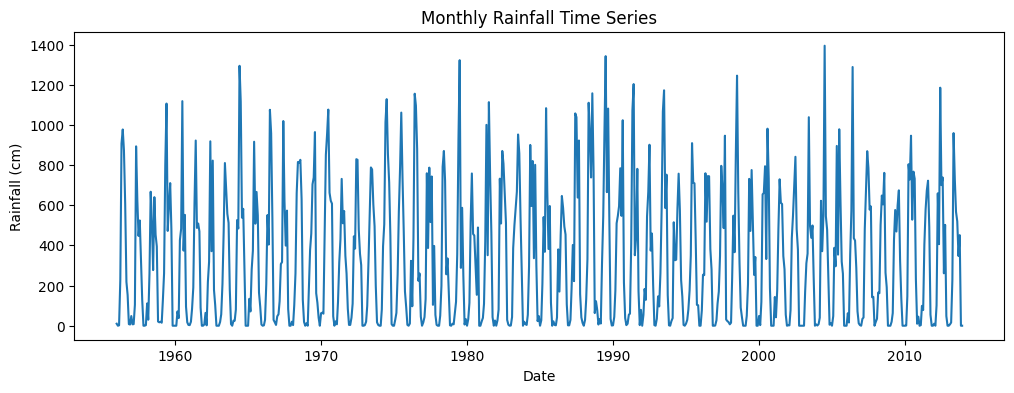

In [12]:


df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str) + '-01')

plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df["Rainfall"], linestyle='-')
plt.title("Monthly Rainfall Time Series")
plt.xlabel("Date")
plt.ylabel("Rainfall (cm)")
plt.show()

In [13]:
df.set_index('Date', inplace=True)
df.drop(columns=['Year', 'Month'], inplace=True)
df.head()

,Max_Temp,Min_Temp,Rainfall,Relative_Humidity,Wind_Speed,Cloud_Coverage,Bright_Sunshine,Flood?
Date,,,,,,,,
1956-01-01,25.8,12.4,10,73.526316,1.344444,1.6,7.715385,0
1956-02-01,29.0,14.2,0,67.035088,1.635185,1.1,8.119231,0
1956-03-01,32.9,18.1,2,65.578947,1.964815,3.2,7.734615,0
1956-04-01,35.8,21.4,229,75.245614,1.914815,3.7,6.863462,0
1956-05-01,35.0,23.4,907,81.333333,1.668519,6.7,6.025000,1


seems like there is a sufficient number of seasonality

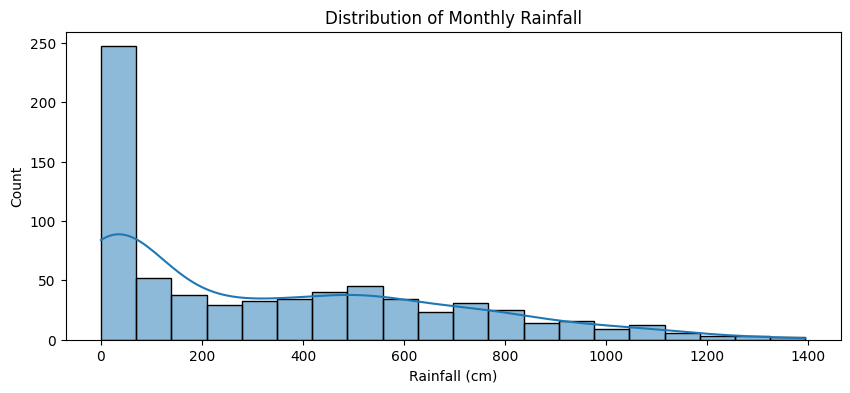

In [14]:
# Histogram for Rainfall and other variables
plt.figure(figsize=(10, 4))
sns.histplot(df["Rainfall"], kde=True, bins=20)
plt.title("Distribution of Monthly Rainfall")
plt.xlabel("Rainfall (cm)")
plt.show()


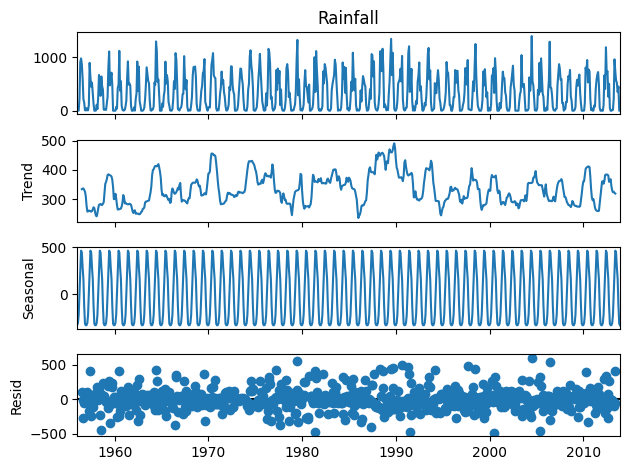

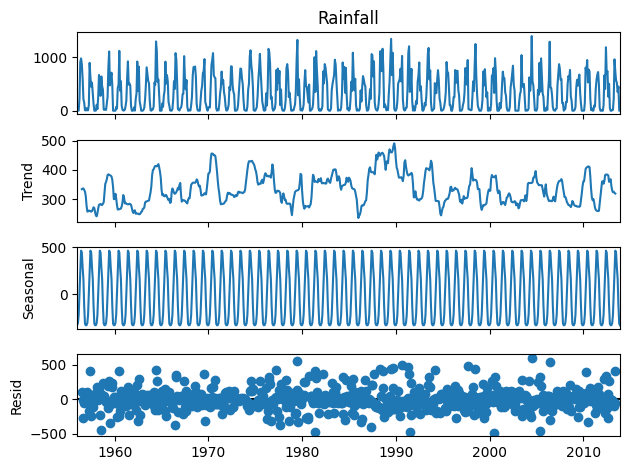

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

results = seasonal_decompose(df['Rainfall'])
results.plot()

In [16]:
# Round all numerical values to two decimal places
df = df.round(2)

# Verify the rounding
print(df.head())

            Max_Temp  Min_Temp  Rainfall  Relative_Humidity  Wind_Speed  \
Date                                                                      
1956-01-01      25.8      12.4        10              73.53        1.34   
1956-02-01      29.0      14.2         0              67.04        1.64   
1956-03-01      32.9      18.1         2              65.58        1.96   
1956-04-01      35.8      21.4       229              75.25        1.91   
1956-05-01      35.0      23.4       907              81.33        1.67   

            Cloud_Coverage  Bright_Sunshine  Flood?  
Date                                                 
1956-01-01             1.6             7.72       0  
1956-02-01             1.1             8.12       0  
1956-03-01             3.2             7.73       0  
1956-04-01             3.7             6.86       0  
1956-05-01             6.7             6.02       1  


In [17]:

# Calculate the minimum rainfall during floods (threshold)
flood_data = df[df['Flood?'] == 1]
threshold_cm = flood_data['Rainfall'].min()

print(f"Minimum Rainfall Threshold for Flood Prediction: {threshold_cm:.1f} cm")

Minimum Rainfall Threshold for Flood Prediction: 399.0 cm


In [18]:


# Use the 90th percentile as the extreme rainfall threshold
extreme_rainfall_threshold = df['Rainfall'].quantile(0.90)

print(f"Extreme Rainfall Threshold (90th percentile): {extreme_rainfall_threshold:.1f} cm")

Extreme Rainfall Threshold (90th percentile): 817.5 cm


In [19]:
features = ['Rainfall', 'Relative_Humidity', 'Wind_Speed', 'Cloud_Coverage', 'Bright_Sunshine']
target = 'Flood?'
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42, shuffle=False)

In [20]:
# Train Decision Tree Model for finding appropriate threshold

tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

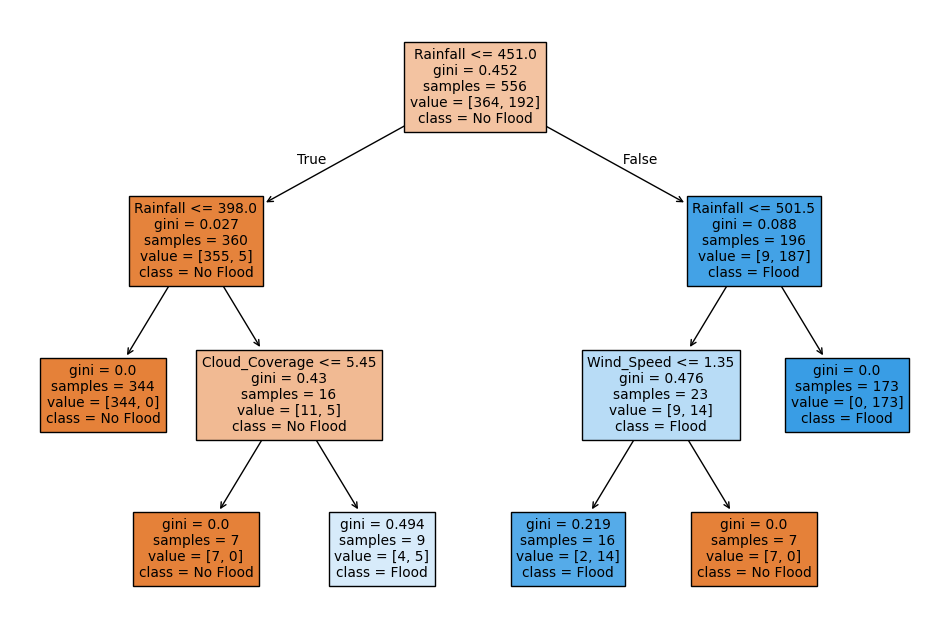

In [21]:

plt.figure(figsize=(12, 8))
plot_tree(tree_model, feature_names=features, class_names=['No Flood', 'Flood'], filled=True)
plt.show()

In [22]:


# Access the threshold value directly (if available)
rainfall_threshold = tree_model.tree_.threshold[tree_model.tree_.feature[0]]

# Check if rainfall is the feature at this node
if features[tree_model.tree_.feature[0]] == 'Rainfall':
    print(f"Estimated Rainfall Threshold for Flood Prediction: {rainfall_threshold:.1f} cm")
else:
    print("Rainfall is not the root node feature. Threshold not found.")

Estimated Rainfall Threshold for Flood Prediction: 451.0 cm


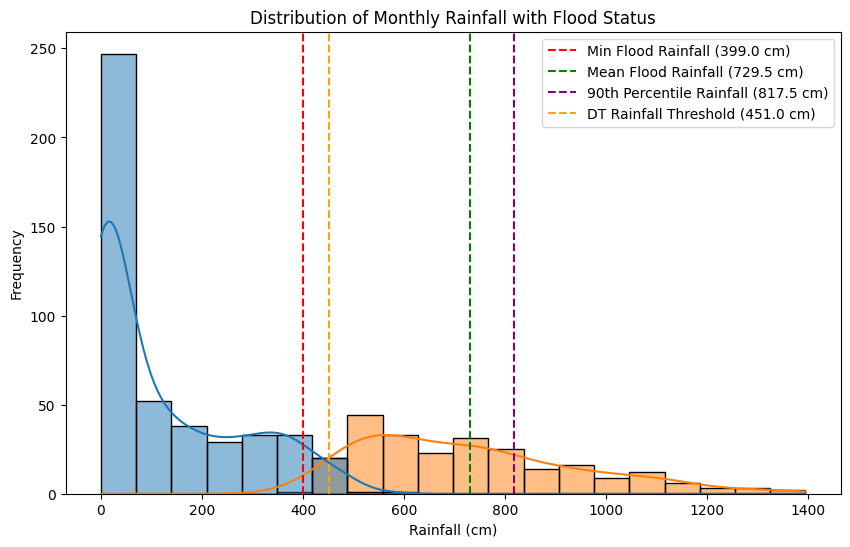


Rainfall Thresholds Identified:
- Minimum Rainfall during Flood: 399.0 cm
- Average Rainfall during Flood: 729.5 cm
- 90th Percentile of Rainfall: 817.5 cm
- Decision Tree Split Threshold (Rainfall): 451.0 cm


In [23]:


import matplotlib.pyplot as plt
threshold_min_flood = df[df['Flood?'] == 1]['Rainfall'].min()
threshold_mean_flood = df[df['Flood?'] == 1]['Rainfall'].mean()
threshold_90th_percentile = df['Rainfall'].quantile(0.90)

# Get threshold from the decision tree model (assuming Rainfall is the root feature)
# We need to find the node where the split is on 'Rainfall' and get the threshold
# This is a bit manual, checking the tree structure
rainfall_threshold_dt = None
if features[tree_model.tree_.feature[0]] == 'Rainfall':
    rainfall_threshold_dt = tree_model.tree_.threshold[tree_model.tree_.feature[0]]


# Show distribution of rainfall with flood occurrences on a histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="Rainfall", hue="Flood?", kde=True, bins=20)
plt.title("Distribution of Monthly Rainfall with Flood Status")
plt.xlabel("Rainfall (cm)")
plt.ylabel("Frequency")

# Add vertical lines for each threshold
plt.axvline(threshold_min_flood, color='red', linestyle='--', label=f'Min Flood Rainfall ({threshold_min_flood:.1f} cm)')
plt.axvline(threshold_mean_flood, color='green', linestyle='--', label=f'Mean Flood Rainfall ({threshold_mean_flood:.1f} cm)')
plt.axvline(threshold_90th_percentile, color='purple', linestyle='--', label=f'90th Percentile Rainfall ({threshold_90th_percentile:.1f} cm)')
if rainfall_threshold_dt is not None:
    plt.axvline(rainfall_threshold_dt, color='orange', linestyle='--', label=f'DT Rainfall Threshold ({rainfall_threshold_dt:.1f} cm)')

plt.legend()
plt.show()

print("\nRainfall Thresholds Identified:")
print(f"- Minimum Rainfall during Flood: {threshold_min_flood:.1f} cm")
print(f"- Average Rainfall during Flood: {threshold_mean_flood:.1f} cm")
print(f"- 90th Percentile of Rainfall: {threshold_90th_percentile:.1f} cm")
if rainfall_threshold_dt is not None:
    print(f"- Decision Tree Split Threshold (Rainfall): {rainfall_threshold_dt:.1f} cm")
else:
     print("- Decision Tree split is not on Rainfall at the root.")

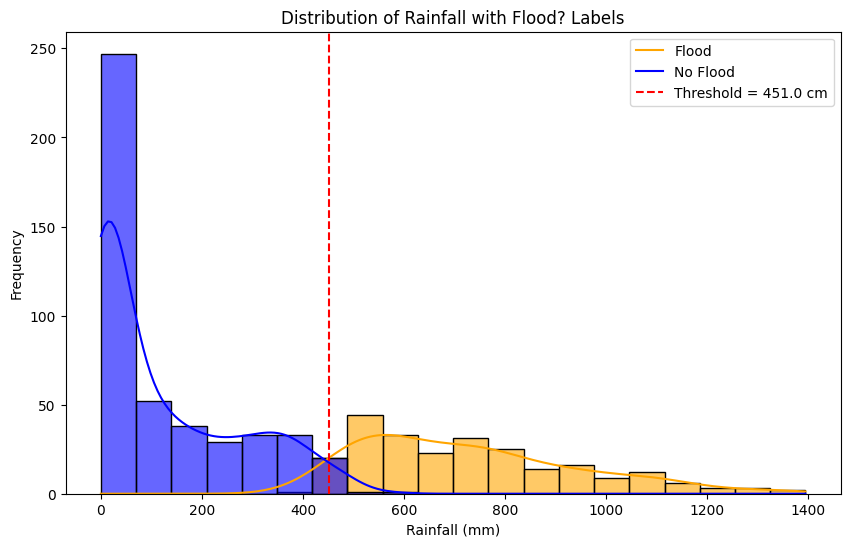

In [24]:

# Define the threshold for flood-triggering rainfall
threshold = 451.0

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Rainfall', hue='Flood?', bins=20, kde=True, palette={0: 'blue', 1: 'orange'}, alpha=0.6)

plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold = {threshold} mm')
plt.legend(['Flood', 'No Flood', 'Threshold = 451.0 cm'], loc='upper right', fontsize=10, frameon=True)
plt.title("Distribution of Rainfall with Flood? Labels")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Frequency")

plt.show()

we have successfully calculated the flood threshold, which is 391.5 cm , and in the above fig we see there's clearly less flood occurence under the threshold.

In [25]:
### Testing For Stationarity

from statsmodels.tsa.stattools import adfuller

test_result=adfuller(df['Rainfall'])
#Ho: It is non stationary
#H1: It is stationary

def adfuller_test(Rainfall):
    result=adfuller(Rainfall)
    labels = ['ADF Test Statistic','p-value','#Lags Used','Number of Observations Used']
    for value,label in zip(result,labels):
        print(label+' : '+str(value) )
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")


adfuller_test(df['Rainfall'])

ADF Test Statistic : -6.841897227309748
p-value : 1.7824715955007176e-09
#Lags Used : 18
Number of Observations Used : 677
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary


In [26]:


import numpy as np
# Perform ADF test for other numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Exclude columns that are not time series or are target/identifier
cols_to_test = [col for col in numerical_cols if col not in ['Year', 'Month', 'Flood?', 'Avg_Temp', 'Temp_RH', 'Cloud_Sunshine', 'Wind_Temp', 'Rainfall_Humidity', 'Wind_Rainfall']]

print("\nPerforming ADF test for other variables:")
for col in cols_to_test:
    print(f"\nTesting stationarity for: {col}")
    adfuller_test(df[col])


Performing ADF test for other variables:

Testing stationarity for: Max_Temp
ADF Test Statistic : -3.471242193603972
p-value : 0.008757111063261006
#Lags Used : 15
Number of Observations Used : 680
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary

Testing stationarity for: Min_Temp
ADF Test Statistic : -3.4895108583985337
p-value : 0.00826059932959174
#Lags Used : 15
Number of Observations Used : 680
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary

Testing stationarity for: Rainfall
ADF Test Statistic : -6.841897227309748
p-value : 1.7824715955007176e-09
#Lags Used : 18
Number of Observations Used : 677
strong evidence against the null hypothesis(Ho), reject the null hypothesis. Data has no unit root and is stationary

Testing stationarity for: Relative_Humidity
ADF Test Statistic : -5.261113022742851
p-value : 6.588150883216415e-06
#Lags Used : 16
N

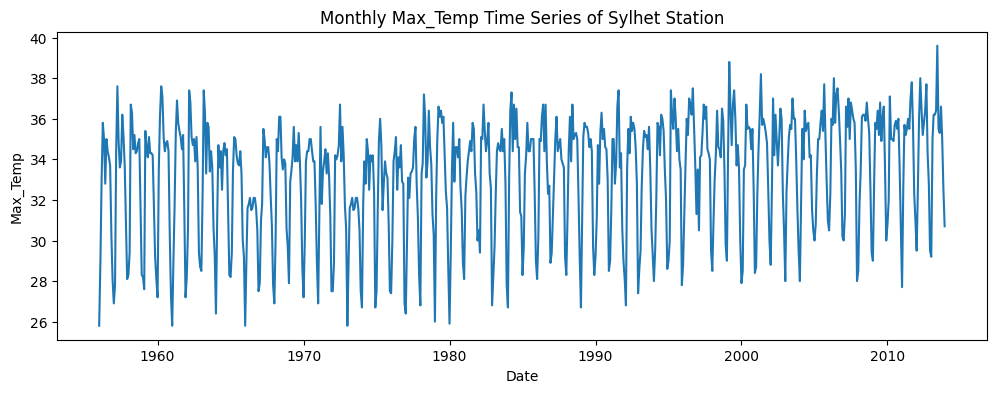

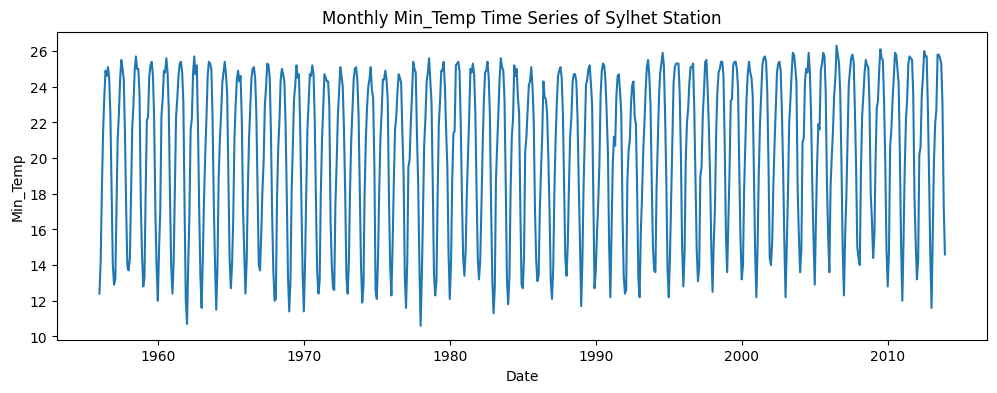

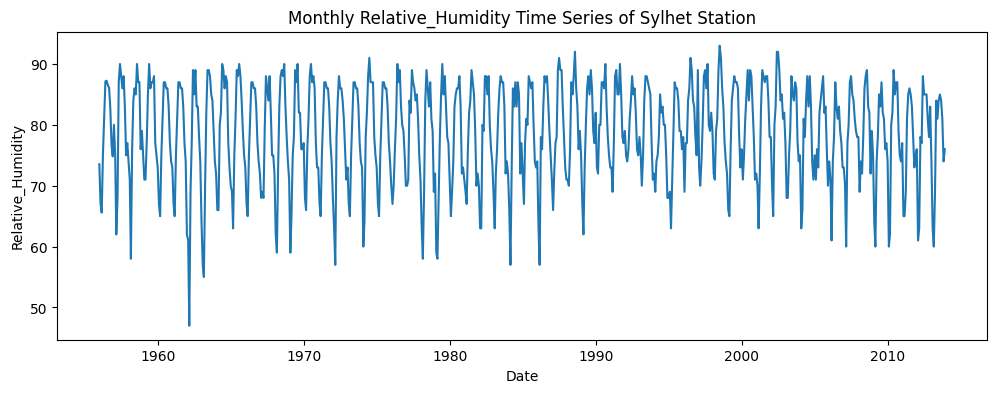

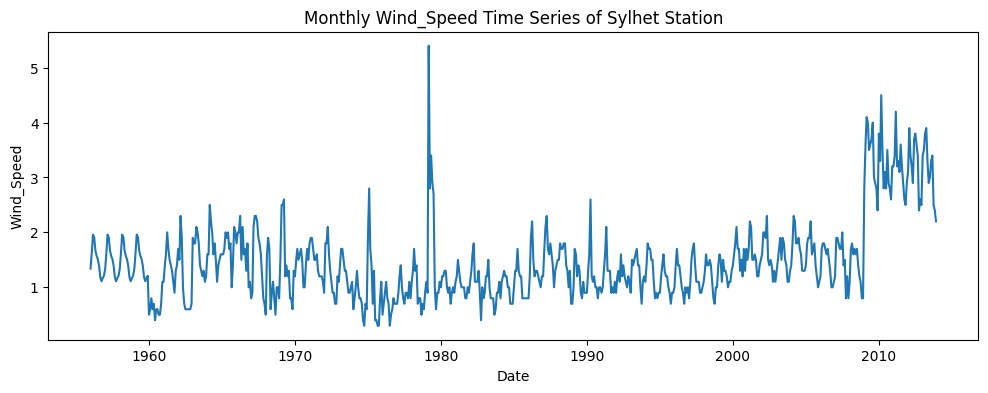

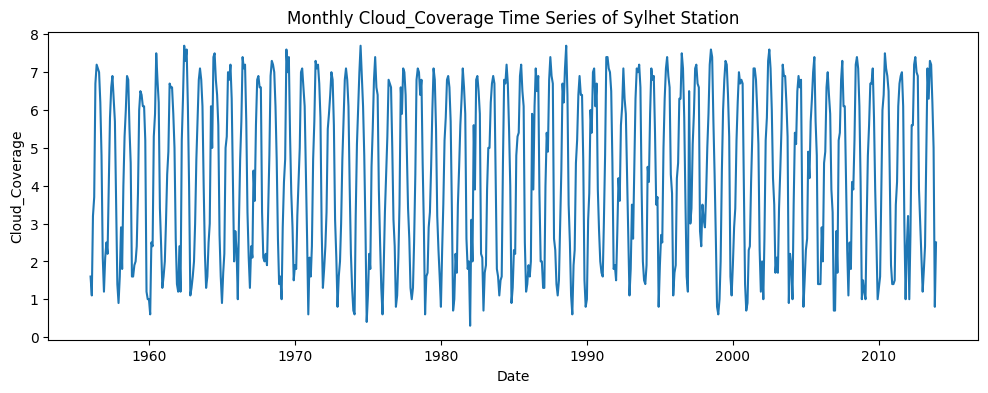

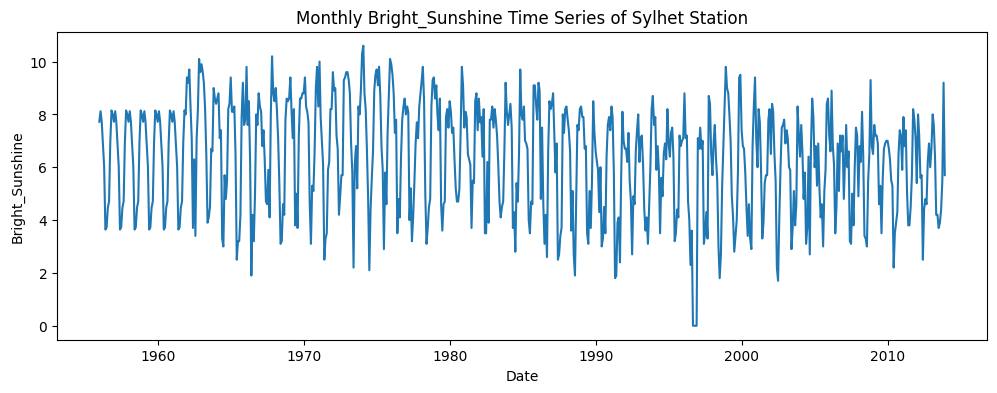

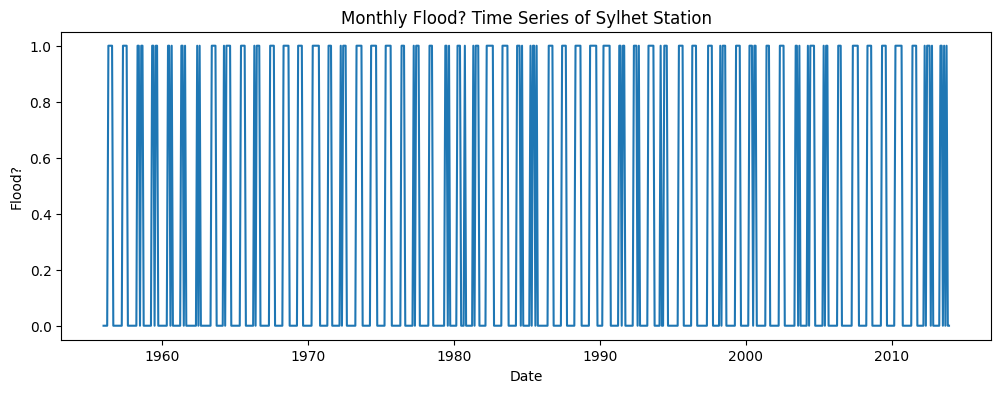

In [27]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remove 'Rainfall' and 'Year' and 'Month' if you don't want to plot them again or separately
cols_to_plot = [col for col in numerical_cols if col not in ['Rainfall', 'Year', 'Month']]

for col in cols_to_plot:
  plt.figure(figsize=(12, 4))
  plt.plot(df.index, df[col], linestyle='-')
  plt.title(f"Monthly {col} Time Series of Sylhet Station")
  plt.xlabel("Date")
  plt.ylabel(col) # You might need to adjust the ylabel based on the variable
  plt.show()

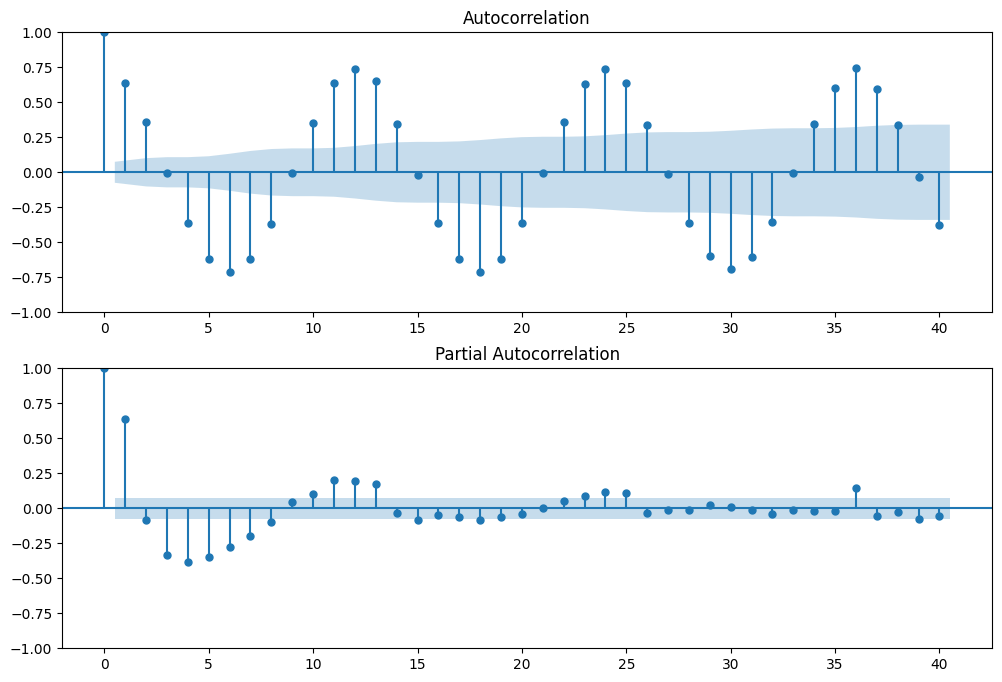

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
# Plot ACF and PACF

fig = plt.figure(figsize=(12,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(df['Rainfall'].iloc[13:],lags=40,ax=ax1)
ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(df['Rainfall'].iloc[13:],lags=40,ax=ax2)

In [29]:
target_col = 'Rainfall'
exog_cols = ['Min_Temp', 'Relative_Humidity', 'Cloud_Coverage']

# ----------- Apply log1p to all variables (log(1 + x)) -----------
df_log = np.log1p(df[[target_col] + exog_cols])
df_log

,Rainfall,Min_Temp,Relative_Humidity,Cloud_Coverage
Date,,,,
1956-01-01,2.397895,2.595255,4.311202,0.955511
1956-02-01,0.000000,2.721295,4.220096,0.741937
1956-03-01,1.098612,2.949688,4.198404,1.435085
1956-04-01,5.438079,3.109061,4.334017,1.547563
1956-05-01,6.811244,3.194583,4.410736,2.041220
...,...,...,...,...
2013-08-01,6.255750,3.280911,4.454347,2.104134
2013-09-01,5.852202,3.269569,4.442651,1.974081
2013-10-01,6.113682,3.182212,4.406719,1.791759


In [30]:
# ----------- Train-test split -----------
train_size = int(len(df_log) * 0.8)
train_df = df_log.iloc[:train_size]
test_df = df_log.iloc[train_size:]

train_target = train_df[target_col]
train_exog = train_df[exog_cols]
test_target = test_df[target_col]
test_exog = test_df[exog_cols]

In [31]:
# ----------- Fit SARIMAX -----------
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train_target,
    exog=train_exog,
    order=(1, 0, 2),             # Tune based on ACF/PACF
    seasonal_order=(1, 0, 2, 12) # Monthly seasonality
)
results = model.fit(disp=False)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


MAE: 88.3008
RMSE: 142.1109
R² Score: 0.8091


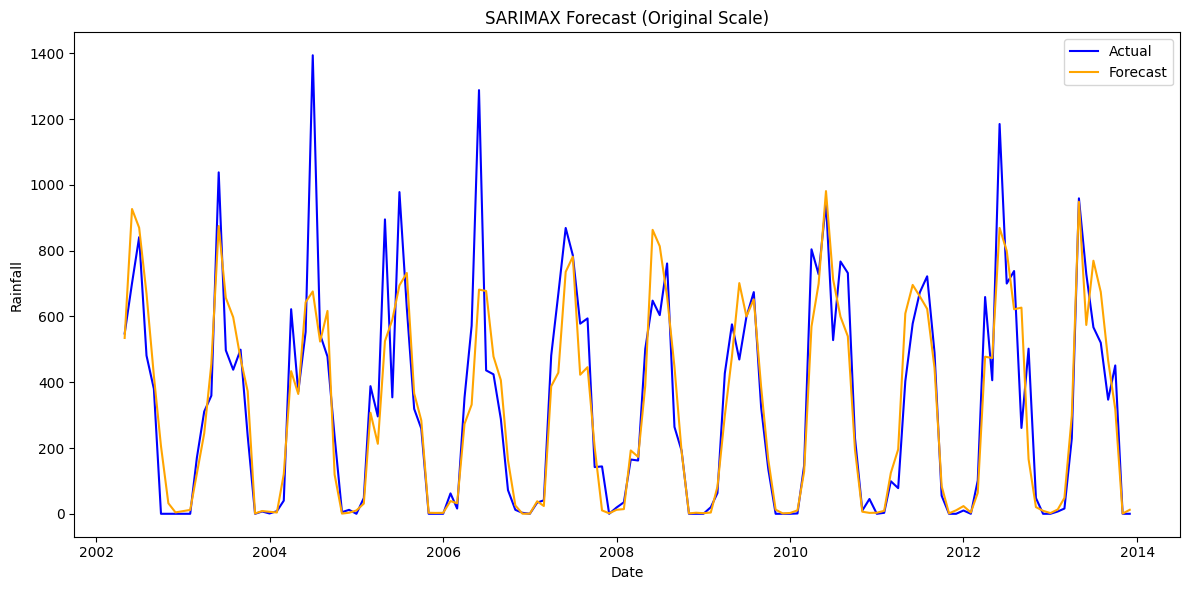

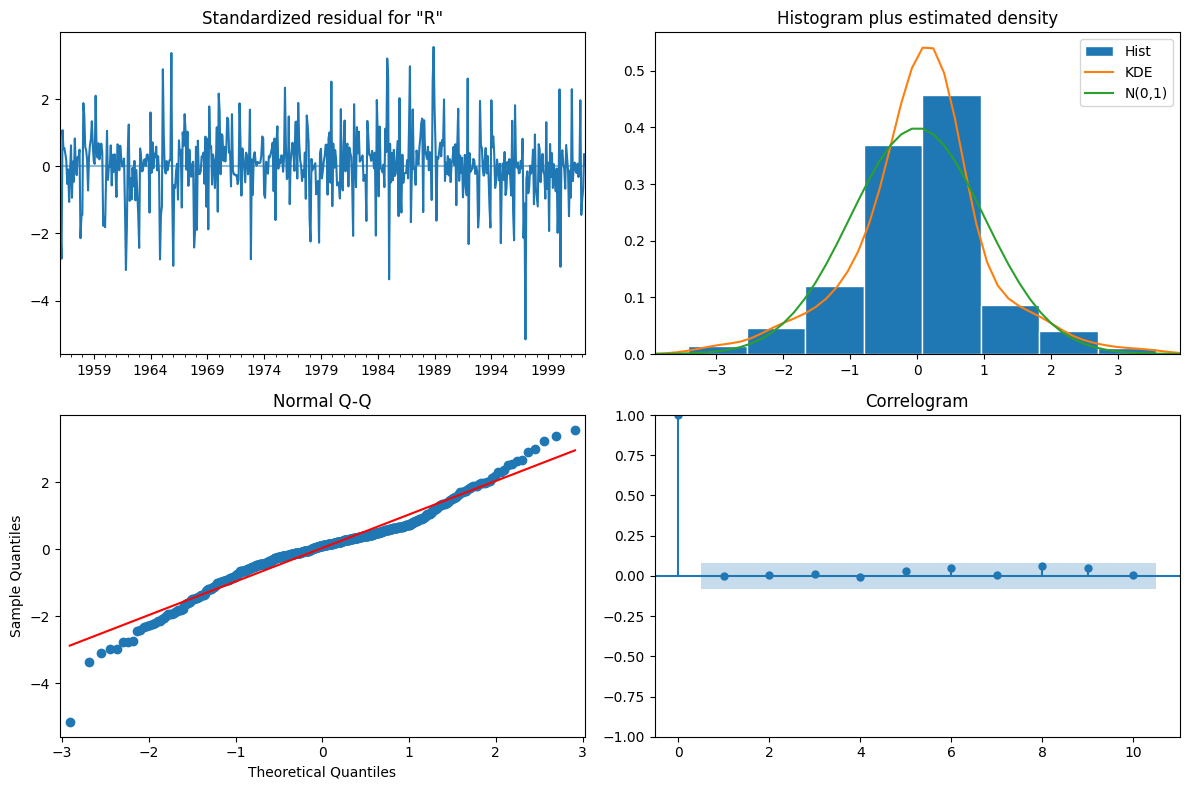

In [32]:
# ----------- Forecast -----------
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

forecast_log = results.forecast(steps=len(test_target), exog=test_exog)

# Inverse of log1p → expm1
forecast = np.expm1(forecast_log)
actual = np.expm1(test_target)

# ----------- Evaluation -----------
mae = mean_absolute_error(actual, forecast)
rmse = np.sqrt(mean_squared_error(actual, forecast))
r2 = r2_score(actual, forecast)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

# ----------- Plot forecast vs actual -----------
plt.figure(figsize=(12, 6))
plt.plot(df.index[-len(actual):], actual, label='Actual', color='blue')
plt.plot(df.index[-len(forecast):], forecast, label='Forecast', color='orange')
plt.title("SARIMAX Forecast (Original Scale)")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.legend()
plt.tight_layout()
plt.show()

# ----------- Residual diagnostics -----------
results.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [33]:
# -------------------------
# Feature Engineering
# -------------------------

# Lag features (1 to 3 months back)
for lag in range(1, 4):
    df[f'Rainfall_lag_{lag}'] = df['Rainfall'].shift(lag)

# Rolling mean & std
df['Rainfall_roll_mean_3'] = df['Rainfall'].rolling(window=3).mean()
df['Rainfall_roll_std_3'] = df['Rainfall'].rolling(window=3).std()

# Temporal features
df['Month'] = df.index.month
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Interaction features
df['Temp_Diff'] = df['Max_Temp'] - df['Min_Temp']
df['Humidity_Temp_Interaction'] = df['Relative_Humidity'] * df['Max_Temp']

# Drop NA after feature generation
df.dropna(inplace=True)


In [34]:

# -------------------------
# Feature Selection
# -------------------------

features = [
    'Max_Temp', 'Min_Temp', 'Relative_Humidity', 'Wind_Speed',
    'Cloud_Coverage', 'Bright_Sunshine',
    'Rainfall_lag_1', 'Rainfall_lag_2', 'Rainfall_lag_3',
    'Rainfall_roll_mean_3', 'Rainfall_roll_std_3',
    'Month_sin', 'Month_cos', 'Temp_Diff', 'Humidity_Temp_Interaction'
]
target = 'Rainfall'

X = df[features]
y = df[target]

# -------------------------
# Train-Test Split
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

In [35]:
# -------------------------
# Hyperparameter Tuning
# -------------------------
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor


param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

tscv = TimeSeriesSplit(n_splits=5)
search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

Fitting 5 folds for each of 20 candidates, totalling 100 fits


Best Parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Mean Absolute Error (MAE): 51.355
Root Mean Squared Error (RMSE): 80.507
R² Score: 0.939


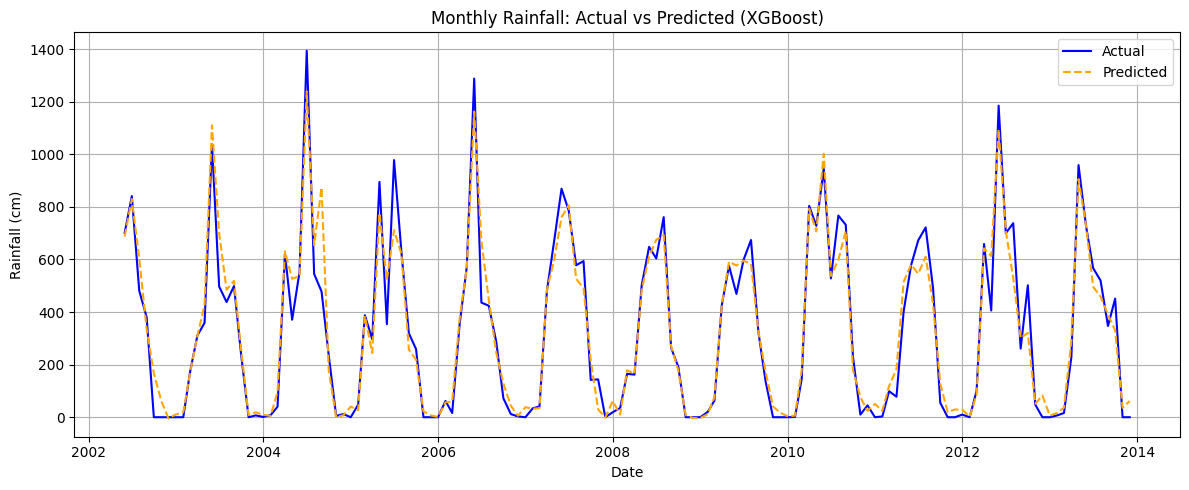

<Figure size 1000x600 with 0 Axes>

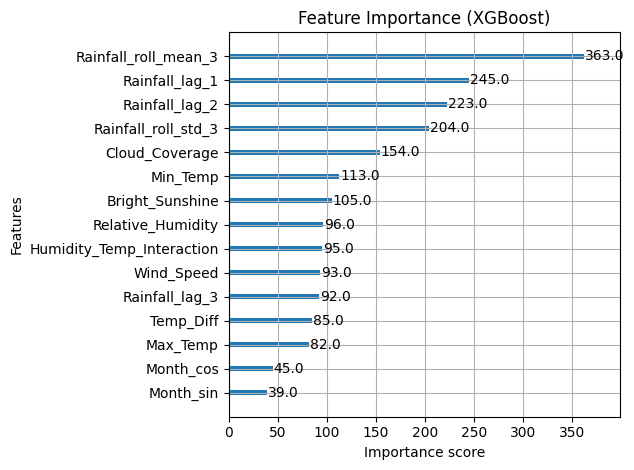

In [36]:
# -------------------------
# Prediction & Evaluation
# -------------------------
from xgboost import plot_importance

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Best Parameters: {search.best_params_}")
print(f"Mean Absolute Error (MAE): {mae:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f}")
print(f"R² Score: {r2:.3f}")

# -------------------------
# Visualization
# -------------------------

results = pd.DataFrame({
    'Date': y_test.index,
    'Actual': y_test.values,
    'Predicted': y_pred
})
results.set_index('Date', inplace=True)

plt.figure(figsize=(12, 5))
plt.plot(results.index, results['Actual'], label='Actual', color='blue')
plt.plot(results.index, results['Predicted'], label='Predicted', color='orange', linestyle='--')
plt.title('Monthly Rainfall: Actual vs Predicted (XGBoost)')
plt.ylabel('Rainfall (cm)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -------------------------
# Feature Importance
# -------------------------

plt.figure(figsize=(10, 6))
plot_importance(best_model, max_num_features=15)
plt.title("Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()

In [37]:
# ---------------------------------------------------
# ✨  Interactive forecast + flood-risk classification
# ---------------------------------------------------

def get_float(prompt):
    """Helper to keep asking until a valid float is entered."""
    while True:
        try:
            return float(input(prompt + ": ").strip())
        except ValueError:
            print("⚠️  Please enter a number.")

def forecast_one_period(model,
                        safe_threshold=399.0,
                        moderate_threshold=451.0,
                        severe_threshold=729.5):
    """
    Ask the user for the latest weather readings +
    the last 3 months' rainfall, then
    return predicted rainfall and a text risk label.
    """
    print("\nEnter the latest observed values —")
    data = {
        "Max_Temp":              get_float("  • Maximum temperature (°C)"),
        "Min_Temp":              get_float("  • Minimum temperature (°C)"),
        "Relative_Humidity":     get_float("  • Relative humidity (%)"),
        "Wind_Speed":            get_float("  • Wind speed (m/s)"),
        "Cloud_Coverage":        get_float("  • Cloud coverage (okta)"),
        "Bright_Sunshine":       get_float("  • Bright sunshine hours"),
        "Rainfall_lag_1":        get_float("  • Rainfall 1 month ago (cm)"),
        "Rainfall_lag_2":        get_float("  • Rainfall 2 months ago (cm)"),
        "Rainfall_lag_3":        get_float("  • Rainfall 3 months ago (cm)")
    }

    # Derive month features from today's date.
    # You can override this if you’re forecasting a specific future month.
    from datetime import datetime
    month = datetime.today().month
    month_sin = np.sin(2 * np.pi * month / 12)
    month_cos = np.cos(2 * np.pi * month / 12)

    # Interaction & rolling-stat placeholders
    data["Rainfall_roll_mean_3"] = (data["Rainfall_lag_1"] +
                                    data["Rainfall_lag_2"] +
                                    data["Rainfall_lag_3"]) / 3
    data["Rainfall_roll_std_3"]  = np.std([data["Rainfall_lag_1"],
                                           data["Rainfall_lag_2"],
                                           data["Rainfall_lag_3"]], ddof=0)
    data["Month_sin"] = month_sin
    data["Month_cos"] = month_cos
    data["Temp_Diff"] = data["Max_Temp"] - data["Min_Temp"]
    data["Humidity_Temp_Interaction"] = (data["Relative_Humidity"] *
                                         data["Max_Temp"])

    # Arrange columns in training order
    feature_order = [
        'Max_Temp', 'Min_Temp', 'Relative_Humidity', 'Wind_Speed',
        'Cloud_Coverage', 'Bright_Sunshine',
        'Rainfall_lag_1', 'Rainfall_lag_2', 'Rainfall_lag_3',
        'Rainfall_roll_mean_3', 'Rainfall_roll_std_3',
        'Month_sin', 'Month_cos', 'Temp_Diff', 'Humidity_Temp_Interaction'
    ]
    X_new = pd.DataFrame([{col: data[col] for col in feature_order}])

    # Predict
    pred = model.predict(X_new)[0]

    # Risk classification
    if   pred < safe_threshold:
        risk = "SAFE"
    elif pred < moderate_threshold:
        risk = "MODERATE"
    elif pred < severe_threshold:
        risk = "HIGH"
    else:
        risk = "SEVERE"

    return pred, risk


# ------------- run it -------------
pred_mm, risk_level = forecast_one_period(best_model)

print(f"\n🔮  Forecast rainfall: {pred_mm:.1f} cm")
print(f"🚦  Flood-risk level:  {risk_level}")



Enter the latest observed values —
  • Maximum temperature (°C): 35
  • Minimum temperature (°C): 24
  • Relative humidity (%): 87
  • Wind speed (m/s): 7
  • Cloud coverage (okta): 7
  • Bright sunshine hours: 7
  • Rainfall 1 month ago (cm): 400
  • Rainfall 2 months ago (cm): 350
  • Rainfall 3 months ago (cm): 230

🔮  Forecast rainfall: 425.2 cm
🚦  Flood-risk level:  MODERATE


In [47]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import math

# Set a seed for reproducibility
np.random.seed(42)

In [48]:
assert 'df' in globals() or 'df' in locals(), "Please define a DataFrame named df with ['Date','Rainfall'] columns, or load it from CSV above."

# Basic cleaning
df = df.copy()
# Reset index to make 'Date' a column
df = df.reset_index()
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

# Keep only target
df = df[['Date','Rainfall']].dropna()
print(df.head())
print(df.tail())

        Date  Rainfall
0 1956-04-01       229
1 1956-05-01       907
2 1956-06-01       977
3 1956-07-01       872
4 1956-08-01       605
          Date  Rainfall
688 2013-08-01       520
689 2013-09-01       347
690 2013-10-01       451
691 2013-11-01         0
692 2013-12-01         0


In [49]:
# 2) Scaling & sequence building
values = df[['Rainfall']].values.astype('float32')

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

def make_sequences(series, lookback=30, horizon=1):
    """Create X (samples, timesteps, features) and y (samples, )"""
    X, y = [], []
    for i in range(lookback, len(series) - horizon + 1):
        X.append(series[i - lookback:i, 0])  # 0 -> single feature (Rainfall)
        y.append(series[i + horizon - 1, 0])
    X = np.array(X)
    y = np.array(y)
    # reshape to (samples, timesteps, features)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

LOOKBACK = 30
HORIZON = 1   # predict next day rainfall

X, y = make_sequences(scaled, lookback=LOOKBACK, horizon=HORIZON)
print("Shapes -> X:", X.shape, " y:", y.shape)

Shapes -> X: (663, 30, 1)  y: (663,)


In [50]:
# 3) Train/Val/Test split (70/15/15)
n = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val     = X[train_end:val_end], y[train_end:val_end]
X_test, y_test   = X[val_end:], y[val_end:]

print(len(X_train), len(X_val), len(X_test))

464 99 100


In [51]:
# (Adapted from your stock LSTM architecture)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

def build_model(input_shape):
    # Reusing your architecture; minor tweaks for rainfall regression
    # Initializing the Neural Network based on LSTM
    model = Sequential()

    # Adding 1st LSTM layer
    model.add(LSTM(units=64, return_sequences=True, input_shape=input_shape))

    # Adding 2nd LSTM layer
    model.add(LSTM(units=10, return_sequences=False))

    # Adding Dropout
    model.add(Dropout(0.25))

    # Output layer
    model.add(Dense(units=1, activation='linear'))

    # Compiling the Neural Network
    model.compile(optimizer = Adam(learning_rate=0.01), loss='mean_squared_error')
    return model

In [52]:
# 4) Build model
input_shape = (X_train.shape[1], X_train.shape[2])  # (timesteps, features)
model = build_model(input_shape)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10)             │         3,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,907 (77.76 KB)

 Trainable params: 19,907 (77.76 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# 5) Train model
EPOCHS = 50
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - loss: 0.0895 - val_loss: 0.0557
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0622 - val_loss: 0.0173
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0305 - val_loss: 0.0210
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0214 - val_loss: 0.0215
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 0.0230 - val_loss: 0.0192
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.0217 - val_loss: 0.0195
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 112ms/step - loss: 0.0183 - val_loss: 0.0176
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - loss: 0.0198 - val_loss: 0.0252
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0247 - val_loss: 0.0208
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0255 - val_loss: 0.0185
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - loss: 0.0209 - val_loss: 0.0196
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0

In [54]:
# 6) Evaluate & inverse-scale predictions
def evaluate_split(X_split, y_split, name='split'):
    y_pred = model.predict(X_split).reshape(-1, 1)
    y_true = y_split.reshape(-1, 1)
    # inverse scale
    inv_pred = scaler.inverse_transform(y_pred).reshape(-1)
    inv_true = scaler.inverse_transform(y_true).reshape(-1)
    mae = mean_absolute_error(inv_true, inv_pred)
    rmse = math.sqrt(mean_squared_error(inv_true, inv_pred))
    r2 = r2_score(inv_true, inv_pred)
    print(f"{name} -> MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")
    return inv_true, inv_pred

train_true, train_pred = evaluate_split(X_train, y_train, 'Train')
val_true, val_pred     = evaluate_split(X_val, y_val, 'Val')
test_true, test_pred   = evaluate_split(X_test, y_test, 'Test')

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
Train -> MAE: 123.0965 | RMSE: 178.5981 | R2: 0.7272
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Val -> MAE: 126.8078 | RMSE: 183.5113 | R2: 0.6956
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
Test -> MAE: 111.4261 | RMSE: 165.2845 | R2: 0.7292


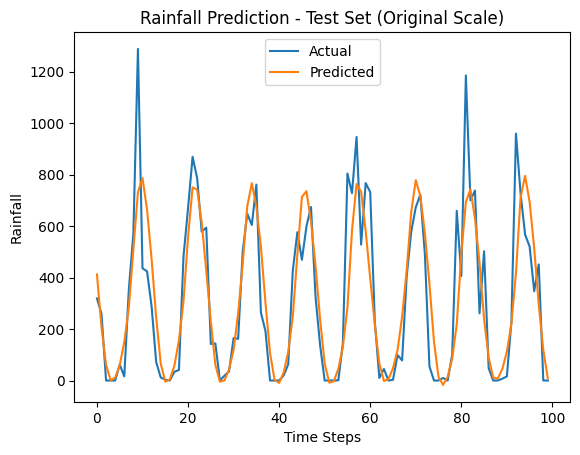

In [55]:
# 7) Plot (original scale)
plt.figure()
plt.plot(test_true, label='Actual')
plt.plot(test_pred, label='Predicted')
plt.title('Rainfall Prediction - Test Set (Original Scale)')
plt.xlabel('Time Steps')
plt.ylabel('Rainfall')
plt.legend()
plt.show()